# Figure 2: Performance Summary

Translation of `Figure02_performanceSummary.m`

## What this notebook does

Shows three performance measures for the online (OL) task:

1. **Example session trajectories**: step sequences from one participant in block 2 at the lowest SNR, color-coded by choice (green = right, red = left).
2. **Congruence per NDT lag**: for each participant, the fraction of trials where the sign of the pigeon position at NDT lag matches the choice direction. The lag with highest congruence is the estimated NDT.
3. **Accuracy vs. median DT**: one point per participant with Clopper–Pearson 90% CIs on accuracy and bootstrap 90% CIs on median DT. Tests whether participants who wait longer (higher DT) are more accurate.

**Data**: online (OL) task, block 2 (penalty block), lowest SNR condition.

## Imports

Imports standard scientific Python libraries and `get_data_table` from the pigeon package. No data loading or filtering here.

## Load data

Loads all OL (open-loop) trials via `get_data_table(task_type='OL')`. This applies the following processing and filtering internally:
- Reads all CSV files in `DATA_DIR/Pigeon_OL/prolificcsvs/`
- Retains only rows with a valid `trial_number`
- Computes `bound`, `DT`, `RT` from step sequences via `get_bounds`
- Marks wall-hit trials (`wall_hit=True`) where the pigeon reached the screen edge (|position| ≥ 0.75)
- Marks trials below the per-(block, SNR) RT reliability cutoff (`rt_below_cutoff=True`); these are excluded by `get_good_trial_array` in downstream analyses
- Applies bias correction from `boundBiasCorrection.mat` if present
- Combines blocks 4–6 into 1–3 (blocked-SNR logic)

No rows are dropped here — all subjects and blocks are retained.

## Compute per-subject summaries

Computes congruence and performance statistics for each subject.

**Data included**: Trials from block 2 (`BLOCK=2`), lowest SNR condition (`min_snr`), with `DT > 0` (excludes trials with zero or negative DT).

**Data excluded**: Trials in other blocks, trials at other SNR levels, trials with `DT ≤ 0`.

Note: wall-hit trials are not explicitly excluded here but were already excluded from bound computation inside `get_data_table`. The `congruence` array is read from the first row of each subject's data (stored during `get_bounds` in `get_data_table`).

## Figure: three performance panels

**Panel 1 (top)**: Step trajectories for `EXAMPLE_SESSION` in block 2 at lowest SNR. Each gray line is one trial; endpoints colored by choice.

**Data included**: Same as above — block 2, lowest SNR, DT > 0, example session only.

**Panel 2 (middle)**: Congruence at each NDT lag (0–4) for all subjects. Each line = one subject; thick black = median.

**Panel 3 (bottom)**: Accuracy vs. median DT per subject. Error bars: Clopper–Pearson 90% CIs (accuracy) and bootstrap 90% CIs (DT). Spearman correlation printed.

In [6]:
import sys
sys.path.insert(0, '..')  # find pigeon package in parent directory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats

from pigeon.data import get_data_table
from pigeon.pathDefaults import FIGURES_DIR

In [7]:
# Load all open-loop trials (matches MATLAB: dataTableOL = getPigeon_dataTable('taskType', 'OL'))
data_table_ol = get_data_table(task_type='OL')

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

In [8]:
# Parameters (match MATLAB defaults)
BLOCK = 2          # which block to use for performance summary
EXAMPLE_SESSION = 10  # subject index for the example trajectory panel

subjects = np.sort(data_table_ol['subject_index'].dropna().unique())
n_subjects = len(subjects)
a_snrs = np.abs(data_table_ol['snr'].to_numpy())
min_snr = np.nanmin(a_snrs)

# Select trials from the target block at the lowest SNR (hardest condition)
lg_good = (
    (data_table_ol['DT'] > 0) &
    (data_table_ol['block_index'] == BLOCK) &
    pd.Series(np.isclose(a_snrs, min_snr), index=data_table_ol.index)
)

congruence_summary = np.full((n_subjects, 5), np.nan)  # congruence at each NDT lag (0–4)
performance_summary = np.full((n_subjects, 2), np.nan)  # columns: accuracy, median DT
n_correct_summary  = np.full(n_subjects, np.nan)
n_trials_summary   = np.full(n_subjects, np.nan)
dt_ci_summary      = np.full((n_subjects, 2), np.nan)   # 90% CI [lo, hi] on median DT

rng = np.random.default_rng(0)

for si, subj in enumerate(subjects):
    ls = data_table_ol['subject_index'] == subj

    # Pull congruence array stored on the first row of each subject
    first_idx = ls[ls].index[0]
    cong = data_table_ol.loc[first_idx, 'congruence']
    if cong is not None and isinstance(cong, np.ndarray) and cong.ndim == 2 and cong.shape[0] >= 5 and cong.shape[1] >= 1:
        congruence_summary[si] = cong[:5, 0]  # first SNR level, first 5 NDT lags

    # Accuracy and median DT for this subject's good trials
    lsg = lg_good & ls
    if lsg.any():
        subset = data_table_ol[lsg]
        n_correct = int(subset['correct'].sum())
        n_trials  = int(subset['correct'].notna().sum())
        dt_vals   = subset['DT'].dropna().values

        performance_summary[si, 0] = n_correct / n_trials
        performance_summary[si, 1] = np.median(dt_vals)
        n_correct_summary[si] = n_correct
        n_trials_summary[si]  = n_trials

        # Bootstrap 90% CI on median DT (1000 resamples)
        if len(dt_vals) > 1:
            boot = rng.choice(dt_vals, size=(1000, len(dt_vals)), replace=True)
            boot_medians = np.median(boot, axis=1)
            dt_ci_summary[si] = np.percentile(boot_medians, [5, 95])

Accuracy = 0.79 [0.68 0.85], Median DT = 4.50 [2.00 6.00]
Spearman acc vs DT = 0.79, p = 0.0000


/var/folders/tp/dghl0fxd0wg0rsyq4p4tzcnc0000gn/T/ipykernel_90947/3338565068.py:26: RuntimeWarning: All-NaN slice encountered
  ax.plot(xax, np.nanmedian(congruence_summary, axis=0), 'k-', linewidth=2)


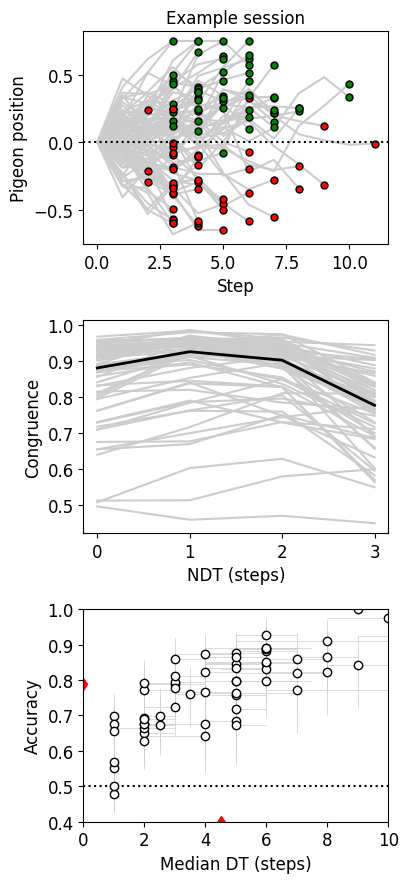

In [9]:
gr = (0.8, 0.8, 0.8)  # light gray for individual traces
fig, axs = plt.subplots(3, 1, figsize=(4.25, 9))

# --- Panel 1: Example session trajectories ---
# Plot each trial's step sequence in gray, color-code the endpoint by choice
ax = axs[0]
ls_ex = lg_good & (data_table_ol['subject_index'] == EXAMPLE_SESSION)
example = data_table_ol[ls_ex][['choice', 'correct', 'steps']]
for _, row in example.iterrows():
    steps = row['steps']
    ax.plot(np.arange(len(steps)), steps, '-', color=gr)
for _, row in example.iterrows():
    steps = row['steps']
    color = 'g' if row['choice'] == 1 else 'r'  # green = right, red = left
    ax.plot(len(steps) - 1, steps[-1], 'ko', markersize=5, markerfacecolor=color)
ax.axhline(0, color='k', linestyle=':')  # decision boundary at zero
ax.set_xlabel('Step')
ax.set_ylabel('Pigeon position')
ax.set_title('Example session')

# --- Panel 2: Congruence per NDT ---
# Each line = one subject; thick black = median across subjects
ax = axs[1]
xax = np.arange(5)
ax.plot(xax, congruence_summary.T, '-', color=gr)
ax.plot(xax, np.nanmedian(congruence_summary, axis=0), 'k-', linewidth=2)
ax.set_xlabel('NDT (steps)')
ax.set_ylabel('Congruence')

# --- Panel 3: Accuracy vs. median DT ---
# Each point = one subject; errorbars = 90% CIs
ax = axs[2]
ax.axhline(0.5, color='k', linestyle=':')  # chance level

# Clopper-Pearson 90% CI on accuracy (y)
acc_lo = np.full(n_subjects, np.nan)
acc_hi = np.full(n_subjects, np.nan)
for si in range(n_subjects):
    if np.isfinite(n_correct_summary[si]):
        k = int(n_correct_summary[si])
        n = int(n_trials_summary[si])
        acc_lo[si] = scipy.stats.beta.ppf(0.05, k,     n - k + 1)
        acc_hi[si] = scipy.stats.beta.ppf(0.95, k + 1, n - k)

xerr = np.array([performance_summary[:, 1] - dt_ci_summary[:, 0],
                 dt_ci_summary[:, 1] - performance_summary[:, 1]])
yerr = np.array([performance_summary[:, 0] - acc_lo,
                 acc_hi - performance_summary[:, 0]])

ax.errorbar(performance_summary[:, 1], performance_summary[:, 0],
            xerr=xerr, yerr=yerr,
            fmt='ko', markerfacecolor='w',
            ecolor=gr, capsize=0, linewidth=0.5, zorder=2)
ax.plot(0, np.nanmedian(performance_summary[:, 0]), 'rd', markerfacecolor='r')      # median accuracy
ax.plot(np.nanmedian(performance_summary[:, 1]), 0.4, 'rd', markerfacecolor='r')    # median DT
ax.set_xlim(0, 10)
ax.set_ylim(0.4, 1)
ax.set_xlabel('Median DT (steps)')
ax.set_ylabel('Accuracy')

# Spearman correlation between accuracy and median DT
valid = np.isfinite(performance_summary[:, 0]) & np.isfinite(performance_summary[:, 1])
r, p = scipy.stats.spearmanr(performance_summary[valid, 0], performance_summary[valid, 1])
print(f'Accuracy = {np.nanpercentile(performance_summary[:,0],50):.2f} '
      f'[{np.nanpercentile(performance_summary[:,0],25):.2f} {np.nanpercentile(performance_summary[:,0],75):.2f}], '
      f'Median DT = {np.nanpercentile(performance_summary[:,1],50):.2f} '
      f'[{np.nanpercentile(performance_summary[:,1],25):.2f} {np.nanpercentile(performance_summary[:,1],75):.2f}]')
print(f'Spearman acc vs DT = {r:.2f}, p = {p:.4f}')

plt.tight_layout()
plt.show()

## Formatted figure

Reproduces the 3-panel figure at publication dimensions matching MATLAB's `getPLOT_axes` call:

```matlab
getPLOT_axes(2, 8.5, [4,4,4], {1,1,1}, 2.0, 1.0, [], 'Pigeons', true)
```

- **Width**: 8.5 cm (1 JNeurosci column)
- **Row heights**: 4 cm each; vertical panel separation 2.0 cm
- **Font size**: 12 pt
- Saves to `Figure02_formatted.pdf`.

/var/folders/tp/dghl0fxd0wg0rsyq4p4tzcnc0000gn/T/ipykernel_90947/1732489129.py:40: RuntimeWarning: All-NaN slice encountered
  ax.plot(xax, np.nanmedian(congruence_summary, axis=0), 'k-', linewidth=2)


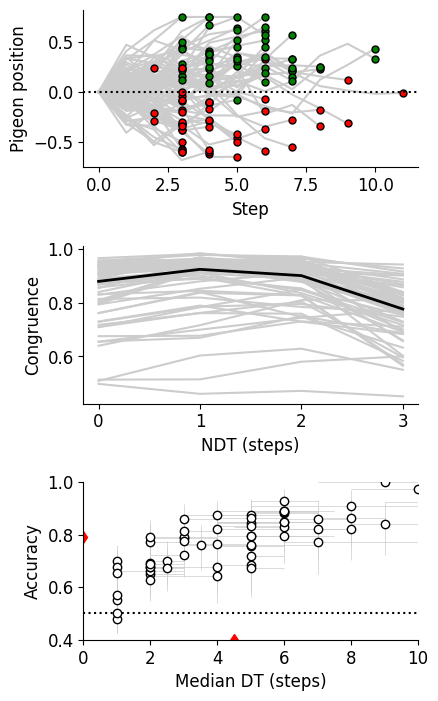

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure02_formatted.pdf


In [10]:
# ── Publication layout matching MATLAB getPLOT_axes(2, 8.5, [4,4,4], {1,1,1}, 2.0, 1.0) ──
import matplotlib.gridspec as gridspec

CM  = 1 / 2.54
WID = 8.5
HTS = [4.0, 4.0, 4.0]
PSH = 2.0
FS  = 12

fig_h       = sum(HTS) + PSH * (len(HTS) - 1)   # 16 cm
hspace_frac = PSH / np.mean(HTS)

fig_fmt = plt.figure(figsize=(WID * CM, fig_h * CM))
gs = gridspec.GridSpec(3, 1, figure=fig_fmt,
                       hspace=hspace_frac,
                       left=0, right=1, bottom=0, top=1)
axs_fmt = [fig_fmt.add_subplot(gs[r]) for r in range(3)]
plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

gr_fmt = (0.8, 0.8, 0.8)

# Panel 1 (top): Example session trajectories
ax = axs_fmt[0]
ls_ex = lg_good & (data_table_ol['subject_index'] == EXAMPLE_SESSION)
example = data_table_ol[ls_ex][['choice', 'correct', 'steps']]
for _, row in example.iterrows():
    ax.plot(np.arange(len(row['steps'])), row['steps'], '-', color=gr_fmt)
for _, row in example.iterrows():
    steps = row['steps']
    color = 'g' if row['choice'] == 1 else 'r'
    ax.plot(len(steps) - 1, steps[-1], 'ko', markersize=5, markerfacecolor=color)
ax.axhline(0, color='k', linestyle=':')
ax.set_xlabel('Step')
ax.set_ylabel('Pigeon position')

# Panel 2 (middle): Congruence per NDT
ax = axs_fmt[1]
xax = np.arange(5)
ax.plot(xax, congruence_summary.T, '-', color=gr_fmt)
ax.plot(xax, np.nanmedian(congruence_summary, axis=0), 'k-', linewidth=2)
ax.set_xlabel('NDT (steps)')
ax.set_ylabel('Congruence')

# Panel 3 (bottom): Accuracy vs. median DT
ax = axs_fmt[2]
ax.axhline(0.5, color='k', linestyle=':')
xerr_fmt = np.array([performance_summary[:, 1] - dt_ci_summary[:, 0],
                     dt_ci_summary[:, 1] - performance_summary[:, 1]])
yerr_fmt = np.array([performance_summary[:, 0] - acc_lo,
                     acc_hi - performance_summary[:, 0]])
ax.errorbar(performance_summary[:, 1], performance_summary[:, 0],
            xerr=xerr_fmt, yerr=yerr_fmt,
            fmt='ko', markerfacecolor='w',
            ecolor=gr_fmt, capsize=0, linewidth=0.5, zorder=2)
ax.plot(0, np.nanmedian(performance_summary[:, 0]), 'rd', markerfacecolor='r')
ax.plot(np.nanmedian(performance_summary[:, 1]), 0.4, 'rd', markerfacecolor='r')
ax.set_xlim(0, 10)
ax.set_ylim(0.4, 1)
ax.set_xlabel('Median DT (steps)')
ax.set_ylabel('Accuracy')

for ax in axs_fmt:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

out = FIGURES_DIR / 'Figure02_formatted.pdf'
fig_fmt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')